Golnaz Sahebi - Spring 2026

# HW05 - Training Linear Models (Part 1)


The aims of this exercise are to introduce the gradient descent method, learn to fit linear regression into nonlinear dataset, and learn to draw and interpret learning curves.

Please note that you should read the chapter 4 “Training Models” of our course book “Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow” 3rd edition by Aurélien Géron to complete the tasks of this exercise successfully.

Embed all your theory answers, drawings, source codes and screen shots directly into this document. Always immediately after the relevant question. 

Return the document into your return box in ItsLearning environment by the deadline. Please remember to mark the number of points that you should get from this exercise according to your own evaluation. The maximum number of points available in this exercise is **10**. You can check the task specific points directly from each task. 

In addition to the course book, it’s also recommendable to use other book and internet sources to supplement the information.


#### 1)	Explain the main ideas behind Gradient Descent method. **(1 point)**

Gradient Descent is an optimization algorithm usually used in ML for minimizing cost function.
It iteratively updates the parameters (θ) in the specific direction of the negative gradient.

Main role of the gradient descent is to reduce the error step by step by adjusting the model parameters.

θ=θ−η⋅∇J(θ) for which η = learning rate and ∇J(θ) = gradient of cost function and its derivative and shows the slope of the function at a specific point, so an approximation of the rate of change at a current point.

If the slope would be positive then moving to the right for example would increase the error so we would want to move towards the left. The opposite with if the slope is negative.

In a few words the gradient descent uses the derivative (slope) to adjust θ in the direction that reduces error the fastest.

#### 2)	You are training a linear regression model? In other words, you are searching for the parameters so that the model best fits into the training set. You are minimizing the mean squared error. In the following situations, which method would you use to calculate these parameters: Batch GD, MiniBatch GD or Stochastic GD? 

a)	There are only a few attributes, but a very large number of rows. You have a lot of computing power. **(1 point)**

I would use Batch gradient descent.

b)	There are many attributes, and a very large number of rows. You have a limited amount of computing power. **(1 point)**

I would use MiniBatch gradient descent.

c)	Justify the above selections. **(1 point)**

Batch gradient descent uses the whole dataset, works good when having high computing power and is accurate too.
MiniBatch gradient descent is better for small subsets, it can decrease computation cost and is efficient, hence better suitable for big datasets with low available computation.
Stochastic gradient descent is a bit more noisy and less stable so not ideal for our choice.

### **3)** Coding Practice

**Objective:** Practice generating synthetic data, applying the exact mathematical solution (The Normal Equation) both manually and via Scikit-Learn, and writing a basic Gradient Descent loop to see how parameters are updated iteratively. 

#### 3.1) Generate a Synthetic Dataset **(1 point)**
In the lecture, we simulated a dataset based on the equation $y = 4 + 3x + \text{noise}$. For this exercise, you will create a dataset based on a different underlying equation: **$y = 5 + 2.5x + \text{noise}$**.

**Instructions:**
1. Import `numpy` and `matplotlib.pyplot`.
2. Set `np.random.seed(42)` for reproducibility.
3. Generate `m = 150` random instances for your feature `X` (values should range between 0 and 2).
4. Generate the target variable `y` using the equation $y = 5 + 2.5X$, and add Gaussian noise using `np.random.randn`.
5. Plot the generated data as a scatter plot (blue dots).

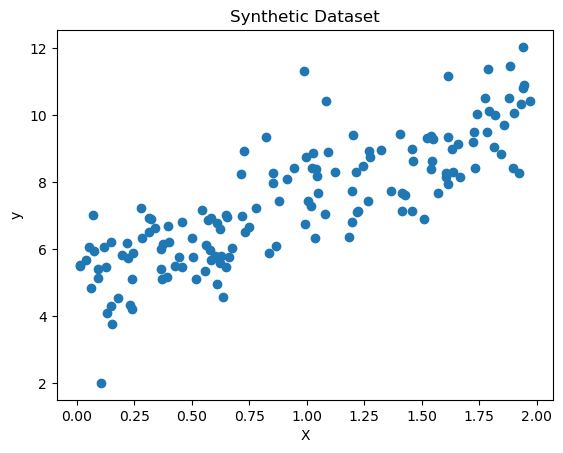

0.011044234247204798 1.9737738732010346


In [6]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

m = 150

X = 2 * np.random.rand(m, 1)

y = 5 + 2.5 * X + np.random.randn(m , 1)

plt.scatter(X, y)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Synthetic Dataset")
plt.show()

print(X.min(), X.max())


#### 3.2) The Exact Method - Normal Equation **(1 point)**
Before relying on Machine Learning libraries, you will calculate the optimal weights ($\theta_0$ and $\theta_1$) manually using the Normal Equation: $\hat{\boldsymbol{\theta}} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$.

**Instructions:**
1. Add the "dummy feature" (a column of 1s) to your `X` matrix so that the matrix multiplication works for the bias term ($\theta_0$). Name this new matrix `X_b`. *(Hint: you can use `np.c_[np.ones((150, 1)), X]`)*
2. Use NumPy's linear algebra module (`np.linalg.inv`) and the matrix multiplication operator (`@`) to compute `theta_best`.
3. Print `theta_best`. 

**Question:** Are the resulting numbers exactly $5$ and $2.5$? Briefly explain why or why not in the comments of your code.

In [7]:
X_b = np.c_[np.ones((150, 1)), X]

theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

print(theta_best)

[[4.96414683]
 [2.58745334]]


#### 3.3) The Scikit-Learn Way **(1 point)**
Now, solve the exact same problem using Scikit-Learn's built-in tools.

**Instructions:**
1. Import `LinearRegression` from `sklearn.linear_model`.
2. Create an instance of the model and `fit` it using your original `X` and `y` (you do not need `X_b` for this).
3. Print the model's intercept (`.intercept_`) and coefficient (`.coef_`). They should match your manual calculation from Task 2.

In [8]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_)

Intercept: [4.96414683]
Coefficient: [[2.58745334]]


#### 3.4) The Iterative Method - Gradient Descent **(3 points)**
Instead of teleporting to the bottom of the cost function valley using the Normal Equation, you will write a small script that "walks" down the mountain.

**Instructions:**
1. Start with a learning rate of `eta = 0.1` and `n_iterations = 25`.
2. Initialize `theta` randomly (e.g., `theta = np.random.randn(2,1)`).
3. Write a `for` loop that runs `n_iterations` times. Inside the loop:
    * Calculate the gradient vector: $\nabla_{\boldsymbol{\theta}} \text{MSE}(\boldsymbol{\theta}) = \frac{2}{m} \mathbf{X}^T (\mathbf{X} \boldsymbol{\theta} - \mathbf{y})$
    * Update the parameters:  $\theta_{\text{new}} = \theta_{\text{old}} - \eta \cdot \frac{\partial J}{\partial \theta}$
4. Print the final `theta` after 25 iterations. It should be very close to the `theta_best` you found in Task 2.
5. **Experiment:** Change your `eta` to `0.8`. Run the loop again and print `theta`. What happens to the numbers, and why? Answer in the comments.

In [9]:
eta = 0.1
n_iterations = 25
m = 150

theta = np.random.randn(2, 1)

for n in range(n_iterations):
    gradients = (2/m) * X_b.T @ (X_b @ theta - y)
    theta = theta - eta * gradients

print("theta with eta = 0.1:", theta)

theta with eta = 0.1: [[4.52235432]
 [2.97593198]]


In [10]:
eta = 0.8
n_iterations = 25
m = 150

theta = np.random.randn(2, 1)

for n in range(n_iterations):
    gradients = (2/m) * X_b.T @ (X_b @ theta - y)
    theta = theta - eta * gradients

print("theta with eta = 0.8:", theta)

theta with eta = 0.8: [[4.76886900e+09]
 [5.42316039e+09]]


For eta = 0.1, theta seems to be converging closer to optimal values
For eta = 0.8, it becomes too large so theta can overshoot or become unstable.